# Module 12: Lineup Position Fit & Gap Analysis

Standard sabermetric lineup construction says: best OBP leads off, best overall hitter bats second, protect the 3-4 hitters. That's a starting point, not an endpoint.

This notebook builds a **lineup position model** using 2021-2025 FanGraphs data from contending teams to define what each spot 1-9 should look like. Then it scores the 2025 Yankees roster against those profiles to identify **gaps** — which lineup spots are well-covered and which archetypes are missing.

This is a **diagnostic tool**, not a lineup card generator. We don't prescribe a batting order — we show where the roster is strong and where it's thin.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="urllib3")

import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from fire_fishman.data.statcast import get_batting_stats

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 8)

In [2]:
# Load 2021-2025 FanGraphs batting stats
batting_dfs = []
for year in range(2021, 2026):
    df = get_batting_stats(year)
    df["Season"] = year
    batting_dfs.append(df)

batting = pd.concat(batting_dfs, ignore_index=True)
qualified = batting[batting["PA"] >= 300].copy()
print(f"Total qualified player-seasons (300+ PA): {len(qualified)}")

# Detect column names
barrel_col = next((c for c in ["Barrel%", "Barrel"] if c in qualified.columns),
                  next((c for c in qualified.columns if "barrel" in c.lower()), None))
k_col = "K%" if "K%" in qualified.columns else "SO%"
bb_col = "BB%" if "BB%" in qualified.columns else None
bsr_col = "BsR" if "BsR" in qualified.columns else None

# Normalize percentage columns to 0-1 if needed
for col in [k_col, bb_col, barrel_col]:
    if col and col in qualified.columns:
        qualified[col] = pd.to_numeric(qualified[col], errors="coerce")
        if qualified[col].median() > 1:
            qualified[col] = qualified[col] / 100

# Ensure numeric for key columns
for col in ["wOBA", "OBP", "SLG", "ISO", "wRC+", "AVG"]:
    if col in qualified.columns:
        qualified[col] = pd.to_numeric(qualified[col], errors="coerce")

print(f"Columns available: barrel={barrel_col}, K={k_col}, BB={bb_col}, BsR={bsr_col}")

Total qualified player-seasons (300+ PA): 1395
Columns available: barrel=Barrel%, K=K%, BB=BB%, BsR=BsR


## Part 1: What Do the Best Teams Actually Do?

Before defining ideal lineup profiles, let's see what contenders actually look like. We'll identify the top offensive teams each year (top 5 by wRC+) and profile their hitters by production tier.

In [3]:
# Identify top offensive teams each year by average wRC+ of qualified hitters
team_offense = qualified.groupby(["Season", "Team"]).agg(
    avg_wRC=pd.NamedAgg(column="wRC+", aggfunc="mean"),
    avg_wOBA=pd.NamedAgg(column="wOBA", aggfunc="mean"),
    n_qualified=pd.NamedAgg(column="Name", aggfunc="count"),
).reset_index()

# Top 5 offensive teams per year
top_offenses = []
for year in qualified["Season"].unique():
    yr = team_offense[team_offense["Season"] == year].nlargest(5, "avg_wRC")
    top_offenses.append(yr)
top_offenses = pd.concat(top_offenses)

# Get all qualified hitters from top offensive teams
contender_hitters = qualified.merge(
    top_offenses[["Season", "Team"]], on=["Season", "Team"]
)

print(f"Top-5 offensive teams per year: {len(top_offenses)} team-seasons")
print(f"Qualified hitters on those teams: {len(contender_hitters)}")
print(f"\nTop offensive teams by year:")
for year in sorted(top_offenses["Season"].unique()):
    teams = top_offenses[top_offenses["Season"] == year]["Team"].tolist()
    print(f"  {year}: {', '.join(teams)}")

Top-5 offensive teams per year: 25 team-seasons
Qualified hitters on those teams: 212

Top offensive teams by year:
  2021: TOR, SFG, ATL, CHW, HOU
  2022: STL, HOU, NYM, LAD, ATL
  2023: ATL, TEX, LAA, TBR, SEA
  2024: LAD, HOU, NYY, BAL, SDP
  2025: SEA, NYY, ARI, LAD, ATH


In [4]:
# Profile what contending teams carry at each production tier
contender_hitters = contender_hitters.sort_values(
    ["Season", "Team", "wOBA"], ascending=[True, True, False]
)
contender_hitters["team_rank"] = contender_hitters.groupby(
    ["Season", "Team"]
).cumcount() + 1

print("CONTENDER LINEUP SLOT PROFILES (avg of top-5 offensive teams, 2021-2025)")
print("=" * 80)

header = f"{'Rank':<6} {'wOBA':>6} {'OBP':>6} {'SLG':>6} {'ISO':>6}"
if k_col: header += f" {'K%':>6}"
if bb_col: header += f" {'BB%':>6}"
if bsr_col and bsr_col in contender_hitters.columns: header += f" {'BsR':>6}"
header += f" {'n':>4}"
print(header)
print("-" * 80)

for rank in range(1, 10):
    slot = contender_hitters[contender_hitters["team_rank"] == rank]
    if len(slot) == 0:
        continue
    line = f"  #{rank:<4} {slot['wOBA'].mean():>6.3f} {slot['OBP'].mean():>6.3f} "
    line += f"{slot['SLG'].mean():>6.3f} {slot['ISO'].mean():>6.3f}"
    if k_col: line += f" {slot[k_col].mean():>5.1%}"
    if bb_col: line += f" {slot[bb_col].mean():>5.1%}"
    if bsr_col and bsr_col in slot.columns: line += f" {slot[bsr_col].mean():>6.1f}"
    line += f" {len(slot):>4}"
    print(line)

CONTENDER LINEUP SLOT PROFILES (avg of top-5 offensive teams, 2021-2025)
Rank     wOBA    OBP    SLG    ISO     K%    BB%    BsR    n
--------------------------------------------------------------------------------
  #1     0.408  0.394  0.576  0.281 20.4% 13.1%    0.2   25
  #2     0.374  0.360  0.517  0.240 20.1% 10.4%   -0.2   25
  #3     0.357  0.348  0.484  0.207 20.4%  8.9%    0.0   25
  #4     0.347  0.340  0.466  0.203 22.3%  9.3%    0.4   25
  #5     0.335  0.335  0.439  0.170 19.0%  8.3%   -0.7   25
  #6     0.322  0.324  0.418  0.158 20.0%  7.7%   -0.2   24
  #7     0.316  0.316  0.412  0.166 23.0%  8.2%    0.4   21
  #8     0.306  0.309  0.393  0.148 21.3%  7.8%   -0.1   19
  #9     0.296  0.294  0.387  0.159 23.9%  7.7%   -0.3   16


## Part 2: Lineup Position Profiles

Using the contender data as baseline, here's what each lineup spot should target. Each profile has weighted metrics and minimum thresholds.

| Spot | Role | Key Metrics | Thresholds |
|------|------|-------------|------------|
| 1 | Table-Setter | OBP (30%), BsR (20%), -K% (20%) | OBP ≥ .340, K% ≤ 20%, BB% ≥ 9% |
| 2 | Best Hitter | wOBA (35%), OBP (25%), ISO (15%) | wOBA ≥ .370, OBP ≥ .370 |
| 3 | OBP + Power | OBP (25%), ISO (25%), wOBA (25%) | OBP ≥ .340, ISO ≥ .180 |
| 4 | Cleanup | ISO (30%), Barrel% (25%), SLG (20%) | ISO ≥ .220, Barrel% ≥ 10% |
| 5 | Power/Contact | -K% (25%), wOBA (25%), ISO (20%) | ISO ≥ .150, K% ≤ 25% |
| 6 | Handedness Break | wOBA (30%), OBP (20%), ISO (15%) | wOBA ≥ .310 |
| 7 | Contact Mfg | -K% (30%), AVG (25%), wOBA (20%) | K% ≤ 20%, AVG ≥ .260 |
| 8 | Specialist | BsR (30%), -K% (20%), Def (20%) | (lowest bar — defense-first) |
| 9 | Second Leadoff | OBP (30%), BB% (20%), wOBA (20%) | OBP ≥ .320, BB% ≥ 9% |

In [5]:
# Define ideal lineup position profiles with measurable thresholds
LINEUP_PROFILES = {
    1: {
        "name": "Table-Setter",
        "description": "Gets on base, sees pitches, runs the bases",
        "weights": {"OBP": 0.30, "wOBA": 0.15, k_col: -0.20, bb_col: 0.15, "BsR": 0.20},
        "thresholds": {"OBP": 0.340, k_col: 0.20, bb_col: 0.09},
    },
    2: {
        "name": "Best Hitter",
        "description": "Highest overall production, can drive in leadoff and get on for 3-4",
        "weights": {"wOBA": 0.35, "OBP": 0.25, "ISO": 0.15, bb_col: 0.10, k_col: -0.15},
        "thresholds": {"wOBA": 0.370, "OBP": 0.370},
    },
    3: {
        "name": "OBP + Power",
        "description": "On base for cleanup, enough ISO to drive runs alone",
        "weights": {"OBP": 0.25, "ISO": 0.25, "wOBA": 0.25, k_col: -0.15, bb_col: 0.10},
        "thresholds": {"OBP": 0.340, "ISO": 0.180},
    },
    4: {
        "name": "Cleanup",
        "description": "Maximum damage — highest power, best barrel rate",
        "weights": {"ISO": 0.30, barrel_col: 0.25, "SLG": 0.20, "wOBA": 0.15, k_col: -0.10},
        "thresholds": {"ISO": 0.220, barrel_col: 0.10},
    },
    5: {
        "name": "Power/Contact",
        "description": "Pop + contact — can't strand runners with K's",
        "weights": {"ISO": 0.20, "wOBA": 0.25, k_col: -0.25, "AVG": 0.15, barrel_col: 0.15},
        "thresholds": {"ISO": 0.150, k_col: 0.25},
    },
    6: {
        "name": "Handedness Break",
        "description": "Solid all-around, breaks up same-handed stretch",
        "weights": {"wOBA": 0.30, "OBP": 0.20, "ISO": 0.15, k_col: -0.15, bb_col: 0.10, "BsR": 0.10},
        "thresholds": {"wOBA": 0.310},
    },
    7: {
        "name": "Contact Manufacturer",
        "description": "Puts ball in play, moves runners, manufactures runs",
        "weights": {k_col: -0.30, "AVG": 0.25, "wOBA": 0.20, "BsR": 0.15, "OBP": 0.10},
        "thresholds": {k_col: 0.20, "AVG": 0.260},
    },
    8: {
        "name": "Specialist",
        "description": "Defense-first, speed value, lowest offensive floor",
        "weights": {"BsR": 0.30, k_col: -0.20, "wOBA": 0.20, "Def": 0.20, "AVG": 0.10},
        "thresholds": {},
    },
    9: {
        "name": "Second Leadoff",
        "description": "Turns lineup over to 1-2, OBP and patience matter",
        "weights": {"OBP": 0.30, bb_col: 0.20, "wOBA": 0.20, k_col: -0.15, "BsR": 0.15},
        "thresholds": {"OBP": 0.320, bb_col: 0.09},
    },
}

print("Lineup Position Profiles Defined")
for spot, profile in LINEUP_PROFILES.items():
    print(f"  #{spot} {profile['name']}: {profile['description']}")

Lineup Position Profiles Defined
  #1 Table-Setter: Gets on base, sees pitches, runs the bases
  #2 Best Hitter: Highest overall production, can drive in leadoff and get on for 3-4
  #3 OBP + Power: On base for cleanup, enough ISO to drive runs alone
  #4 Cleanup: Maximum damage — highest power, best barrel rate
  #5 Power/Contact: Pop + contact — can't strand runners with K's
  #6 Handedness Break: Solid all-around, breaks up same-handed stretch
  #7 Contact Manufacturer: Puts ball in play, moves runners, manufactures runs
  #8 Specialist: Defense-first, speed value, lowest offensive floor
  #9 Second Leadoff: Turns lineup over to 1-2, OBP and patience matter


In [6]:
# Score each player against each lineup position
# Uses z-scores so different metrics are comparable

def compute_fit_scores(players_df, profiles, stat_cols):
    """Score every player against every lineup position.
    
    Returns a DataFrame with shape (n_players, 9) where each cell
    is a 0-100 fit score for that player in that lineup spot.
    """
    z_scores = pd.DataFrame(index=players_df.index)
    for col in stat_cols:
        if col and col in players_df.columns:
            vals = pd.to_numeric(players_df[col], errors="coerce")
            z_scores[col] = (vals - vals.mean()) / vals.std()
    
    fit_matrix = pd.DataFrame(index=players_df.index)
    
    for spot, profile in profiles.items():
        score = pd.Series(0.0, index=players_df.index)
        total_weight = 0
        
        for stat, weight in profile["weights"].items():
            if stat and stat in z_scores.columns:
                score += weight * z_scores[stat]
                total_weight += abs(weight)
        
        if total_weight > 0:
            score = score / total_weight
        
        score_min, score_max = score.min(), score.max()
        if score_max > score_min:
            fit_matrix[spot] = ((score - score_min) / (score_max - score_min) * 100).round(1)
        else:
            fit_matrix[spot] = 50.0
    
    return fit_matrix


stat_cols = ["wOBA", "OBP", "SLG", "ISO", "AVG", k_col, bb_col,
             barrel_col, bsr_col, "Def"]
stat_cols = [c for c in stat_cols if c and c in qualified.columns]

fit_scores = compute_fit_scores(qualified, LINEUP_PROFILES, stat_cols)
fit_scores["Name"] = qualified["Name"].values
fit_scores["Team"] = qualified["Team"].values
fit_scores["Season"] = qualified["Season"].values
fit_scores["wOBA"] = qualified["wOBA"].values

print(f"Fit scores computed for {len(fit_scores)} player-seasons")
print(f"\nTop 5 fit scores for each lineup spot (all teams, 2021-2025):")
for spot in range(1, 10):
    top = fit_scores.nlargest(5, spot)[["Name", "Season", "Team", spot]]
    names = ", ".join(f"{r['Name']} ({r[spot]:.0f})" for _, r in top.iterrows())
    print(f"  #{spot} {LINEUP_PROFILES[spot]['name']}: {names}")

Fit scores computed for 1395 player-seasons

Top 5 fit scores for each lineup spot (all teams, 2021-2025):
  #1 Table-Setter: Ronald Acuna Jr. (100), Juan Soto (100), Aaron Judge (96), Aaron Judge (88), Shohei Ohtani (88)
  #2 Best Hitter: Aaron Judge (100), Aaron Judge (96), Aaron Judge (90), Juan Soto (90), Bryce Harper (84)
  #3 OBP + Power: Aaron Judge (100), Aaron Judge (96), Aaron Judge (90), Juan Soto (87), Shohei Ohtani (84)
  #4 Cleanup: Aaron Judge (100), Aaron Judge (97), Aaron Judge (94), Aaron Judge (88), Shohei Ohtani (85)
  #5 Power/Contact: Aaron Judge (100), Aaron Judge (96), Aaron Judge (94), Ronald Acuna Jr. (88), Shohei Ohtani (86)
  #6 Handedness Break: Aaron Judge (100), Aaron Judge (94), Aaron Judge (91), Ronald Acuna Jr. (88), Juan Soto (88)
  #7 Contact Manufacturer: Ronald Acuna Jr. (100), Luis Arraez (89), Bobby Witt Jr. (86), Freddie Freeman (86), Trea Turner (83)
  #8 Specialist: Ronald Acuna Jr. (100), Bobby Witt Jr. (95), Bobby Witt Jr. (93), Trea Turner 

## Part 3: 2025 Yankees Gap Analysis

Now the diagnostic. Score every 2025 Yankee against every lineup spot, then identify which roles are well-covered and which are gaps.

This is **not** a batting order — a player can be the best fit for multiple spots. The point is to show: does the roster have the archetypes a contending lineup needs?

In [7]:
# 2025 Yankees qualified hitters
nyy_25 = qualified[qualified["Season"] == 2025].copy()
nyy_25_teams = nyy_25[nyy_25["Team"] == "NYY"].copy()

print(f"2025 Yankees qualified hitters (300+ PA): {len(nyy_25_teams)}")
print()

display_cols = ["Name", "wOBA", "OBP", "SLG", "ISO", k_col, bb_col]
if barrel_col:
    display_cols.append(barrel_col)
if bsr_col and bsr_col in nyy_25_teams.columns:
    display_cols.append(bsr_col)
display_cols = [c for c in display_cols if c and c in nyy_25_teams.columns]

print(nyy_25_teams[display_cols].sort_values("wOBA", ascending=False).to_string(index=False))

2025 Yankees qualified hitters (300+ PA): 9

             Name  wOBA   OBP   SLG   ISO    K%   BB%  Barrel%  BsR
      Aaron Judge 0.463 0.457 0.688 0.357 0.236 0.183    0.247 -4.1
         Ben Rice 0.358 0.337 0.499 0.244 0.189 0.094    0.154 -2.0
    Trent Grisham 0.353 0.348 0.464 0.229 0.236 0.141    0.142 -3.0
Jazz Chisholm Jr. 0.349 0.332 0.481 0.238 0.279 0.109    0.150  2.9
   Cody Bellinger 0.347 0.334 0.480 0.207 0.137 0.087    0.075  0.9
 Paul Goldschmidt 0.316 0.328 0.403 0.129 0.187 0.067    0.079 -2.6
 Jasson Dominguez 0.316 0.331 0.388 0.131 0.268 0.096    0.070  3.0
     Austin Wells 0.302 0.275 0.436 0.217 0.263 0.067    0.102 -0.6
    Anthony Volpe 0.286 0.272 0.391 0.180 0.252 0.072    0.105  1.1


In [8]:
# Compute fit scores for ALL qualified hitters (league-wide z-scores)
all_fit = compute_fit_scores(qualified, LINEUP_PROFILES, stat_cols)
all_fit["Name"] = qualified["Name"].values
all_fit["Team"] = qualified["Team"].values
all_fit["Season"] = qualified["Season"].values

# Slice to 2025 Yankees
nyy_fit = all_fit[(all_fit["Team"] == "NYY") & (all_fit["Season"] == 2025)].copy()

# Anchor the star: Judge locks into Spot 2 (Best Hitter). He's generational —
# of course he'd score highest everywhere. The diagnostic question is what the
# REST of the roster looks like after you slot him.
judge_row = nyy_fit[nyy_fit["Name"] == "Aaron Judge"]
judge_score = judge_row[2].values[0] if len(judge_row) > 0 else None

# Remove Judge from the pool for remaining spots
nyy_rest = nyy_fit[nyy_fit["Name"] != "Aaron Judge"].copy()

print(f"2025 Yankees fit scores (league-wide z-scoring, {len(qualified)} player-seasons)")
print(f"Anchor: Aaron Judge → Spot #2 Best Hitter (fit: {judge_score:.1f})\n")

# Gap analysis for spots 1, 3-9 using remaining roster
gap_analysis = []

# Spot 2 is anchored
gap_analysis.append({
    "spot": 2,
    "role": LINEUP_PROFILES[2]["name"],
    "best_fit": "Aaron Judge",
    "best_score": judge_score,
    "backup": nyy_rest.nlargest(1, 2)["Name"].values[0],
    "backup_score": nyy_rest[2].max(),
})

for spot in [1, 3, 4, 5, 6, 7, 8, 9]:
    best_idx = nyy_rest[spot].idxmax()
    best_name = nyy_rest.loc[best_idx, "Name"]
    best_score = nyy_rest.loc[best_idx, spot]
    
    second_idx = nyy_rest[spot].nlargest(2).index[-1]
    second_name = nyy_rest.loc[second_idx, "Name"]
    second_score = nyy_rest.loc[second_idx, spot]
    
    gap_analysis.append({
        "spot": spot,
        "role": LINEUP_PROFILES[spot]["name"],
        "best_fit": best_name,
        "best_score": best_score,
        "backup": second_name,
        "backup_score": second_score,
    })

gap_df = pd.DataFrame(gap_analysis).sort_values("spot").reset_index(drop=True)

print("GAP ANALYSIS: 2025 YANKEES (Judge anchored at #2)")
print("=" * 80)
print(f"{'Spot':<6} {'Role':<22} {'Best Fit':<22} {'Score':>6} {'Backup':<22} {'Score':>6}  Status")
print("-" * 80)

for _, row in gap_df.iterrows():
    score = row["best_score"]
    if score >= 70:
        status = "STRONG"
    elif score >= 50:
        status = "ADEQUATE"
    else:
        status = "** GAP **"
    marker = " ★" if row["best_fit"] == "Aaron Judge" else ""
    print(f"  #{row['spot']:<4} {row['role']:<22} {row['best_fit'] + marker:<22} {score:>5.1f}  "
          f"{row['backup']:<22} {row['backup_score']:>5.1f}  {status}")

strong = (gap_df["best_score"] >= 70).sum()
adequate = ((gap_df["best_score"] >= 50) & (gap_df["best_score"] < 70)).sum()
gaps = (gap_df["best_score"] < 50).sum()
print(f"\nStrong fits (70+): {strong}/9")
print(f"Adequate (50-70): {adequate}/9")
print(f"Gaps (<50): {gaps}/9")

# Flag overloaded players (excluding Judge who is anchored)
from collections import Counter
rest_counts = Counter(gap_df[gap_df["best_fit"] != "Aaron Judge"]["best_fit"])
overloaded = {k: v for k, v in rest_counts.items() if v > 1}
if overloaded:
    print(f"\nOverloaded players (best fit for multiple remaining spots):")
    for name, count in overloaded.items():
        spots = gap_df[gap_df["best_fit"] == name]["role"].tolist()
        print(f"  {name}: {', '.join(spots)} ({count} spots)")
    print("  → Not enough distinct archetypes to fill the lineup.")

if gaps > 0:
    print(f"\nGap positions need:")
    for _, row in gap_df[gap_df["best_score"] < 50].iterrows():
        spot = int(row["spot"])
        profile = LINEUP_PROFILES[spot]
        print(f"  #{spot} {profile['name']}: {profile['description']}")
        if profile["thresholds"]:
            for k, v in profile["thresholds"].items():
                if k:
                    direction = "<=" if k == k_col else ">="
                    print(f"      {k} {direction} {v}")

2025 Yankees fit scores (league-wide z-scoring, 1395 player-seasons)
Anchor: Aaron Judge → Spot #2 Best Hitter (fit: 96.4)

GAP ANALYSIS: 2025 YANKEES (Judge anchored at #2)
Spot   Role                   Best Fit                Score Backup                  Score  Status
--------------------------------------------------------------------------------
  #1    Table-Setter           Cody Bellinger          55.6  Trent Grisham           50.8  ADEQUATE
  #2    Best Hitter            Aaron Judge ★           96.4  Trent Grisham           53.3  STRONG
  #3    OBP + Power            Trent Grisham           53.5  Ben Rice                53.2  ADEQUATE
  #4    Cleanup                Ben Rice                58.2  Jazz Chisholm Jr.       53.0  ADEQUATE
  #5    Power/Contact          Ben Rice                60.4  Cody Bellinger          56.5  ADEQUATE
  #6    Handedness Break       Cody Bellinger          51.5  Ben Rice                51.5  ADEQUATE
  #7    Contact Manufacturer   Cody Bellinger    

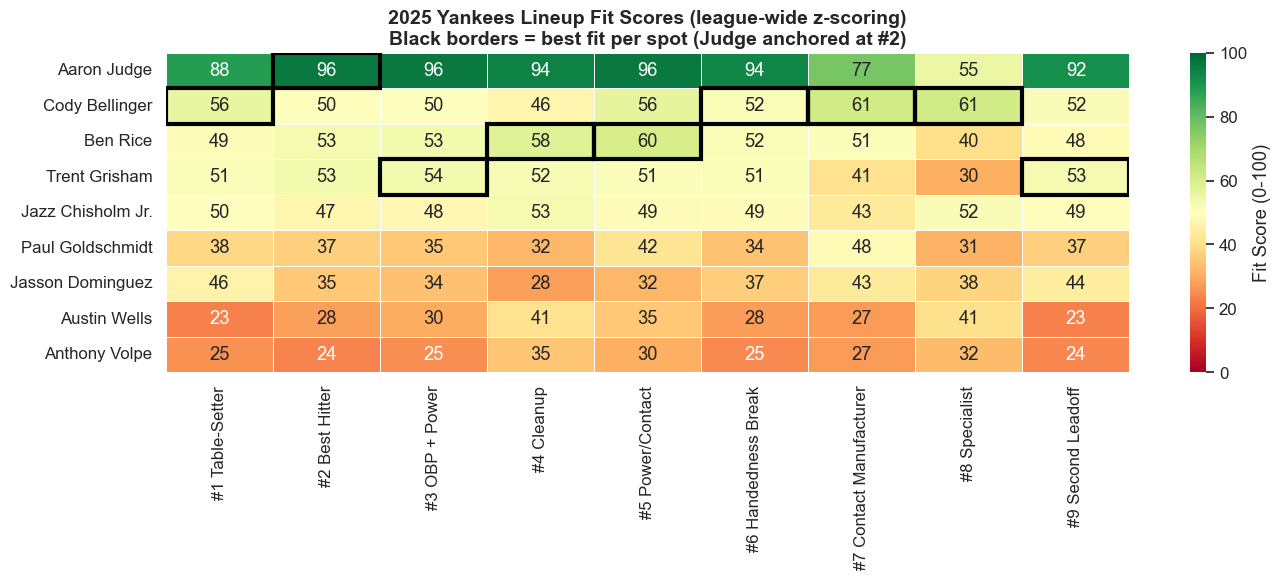

In [9]:
# Figure 1: Fit score heatmap — all Yankees vs all spots (full picture)
# Judge is included to show he dominates; the gap analysis below removes him
fig, ax = plt.subplots(figsize=(14, max(6, len(nyy_fit) * 0.6)))

spot_cols = [c for c in range(1, 10) if c in nyy_fit.columns]
plot_data = nyy_fit.set_index("Name")[spot_cols].copy()
plot_data = plot_data.loc[plot_data.max(axis=1).sort_values(ascending=False).index]

col_labels = [f"#{s} {LINEUP_PROFILES[s]['name']}" for s in spot_cols]
plot_data.columns = col_labels

sns.heatmap(plot_data, annot=True, fmt=".0f", cmap="RdYlGn",
            vmin=0, vmax=100, linewidths=0.5,
            cbar_kws={"label": "Fit Score (0-100)"},
            ax=ax)

# Mark gap analysis assignments (Judge anchored at #2, rest by best fit)
for _, row in gap_df.iterrows():
    player_name = row["best_fit"]
    spot = int(row["spot"])
    if player_name in plot_data.index:
        y_pos = list(plot_data.index).index(player_name)
        x_pos = spot - 1
        ax.add_patch(plt.Rectangle((x_pos, y_pos), 1, 1,
                                    fill=False, edgecolor="black", linewidth=3))

ax.set_title("2025 Yankees Lineup Fit Scores (league-wide z-scoring)\n"
             "Black borders = best fit per spot (Judge anchored at #2)",
             fontsize=14, fontweight="bold")
ax.set_ylabel("")
ax.set_xlabel("")

plt.tight_layout()
plt.savefig("../outputs/figures/yankees_lineup_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

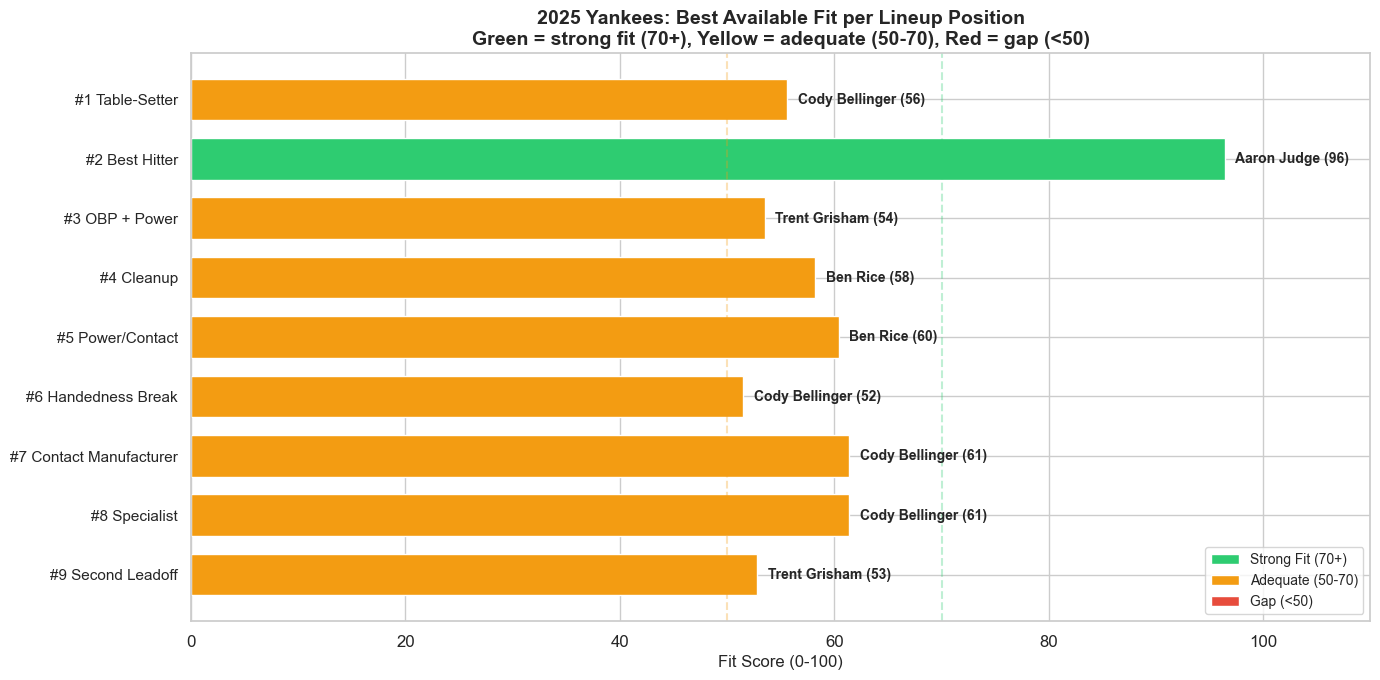

In [10]:
# Figure 2: Gap analysis bar chart
fig, ax = plt.subplots(figsize=(14, 7))

spots = [f"#{int(r['spot'])} {r['role']}" for _, r in gap_df.iterrows()]
scores = gap_df["best_score"].values
names = gap_df["best_fit"].values

colors = ["#2ecc71" if s >= 70 else "#f39c12" if s >= 50 else "#e74c3c" for s in scores]

bars = ax.barh(range(len(spots)), scores, color=colors, edgecolor="white", height=0.7)

for i, (bar, name, score) in enumerate(zip(bars, names, scores)):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{name} ({score:.0f})", va="center", fontsize=10, fontweight="bold")

ax.set_yticks(range(len(spots)))
ax.set_yticklabels(spots, fontsize=11)
ax.set_xlabel("Fit Score (0-100)", fontsize=12)
ax.set_title("2025 Yankees: Best Available Fit per Lineup Position\n"
             "Green = strong fit (70+), Yellow = adequate (50-70), Red = gap (<50)",
             fontsize=14, fontweight="bold")
ax.set_xlim(0, 110)
ax.axvline(70, color="#2ecc71", linestyle="--", alpha=0.3)
ax.axvline(50, color="#f39c12", linestyle="--", alpha=0.3)
ax.invert_yaxis()

legend_elements = [
    mpatches.Patch(facecolor="#2ecc71", label="Strong Fit (70+)"),
    mpatches.Patch(facecolor="#f39c12", label="Adequate (50-70)"),
    mpatches.Patch(facecolor="#e74c3c", label="Gap (<50)"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("../outputs/figures/yankees_lineup_gaps.png", dpi=150, bbox_inches="tight")
plt.show()

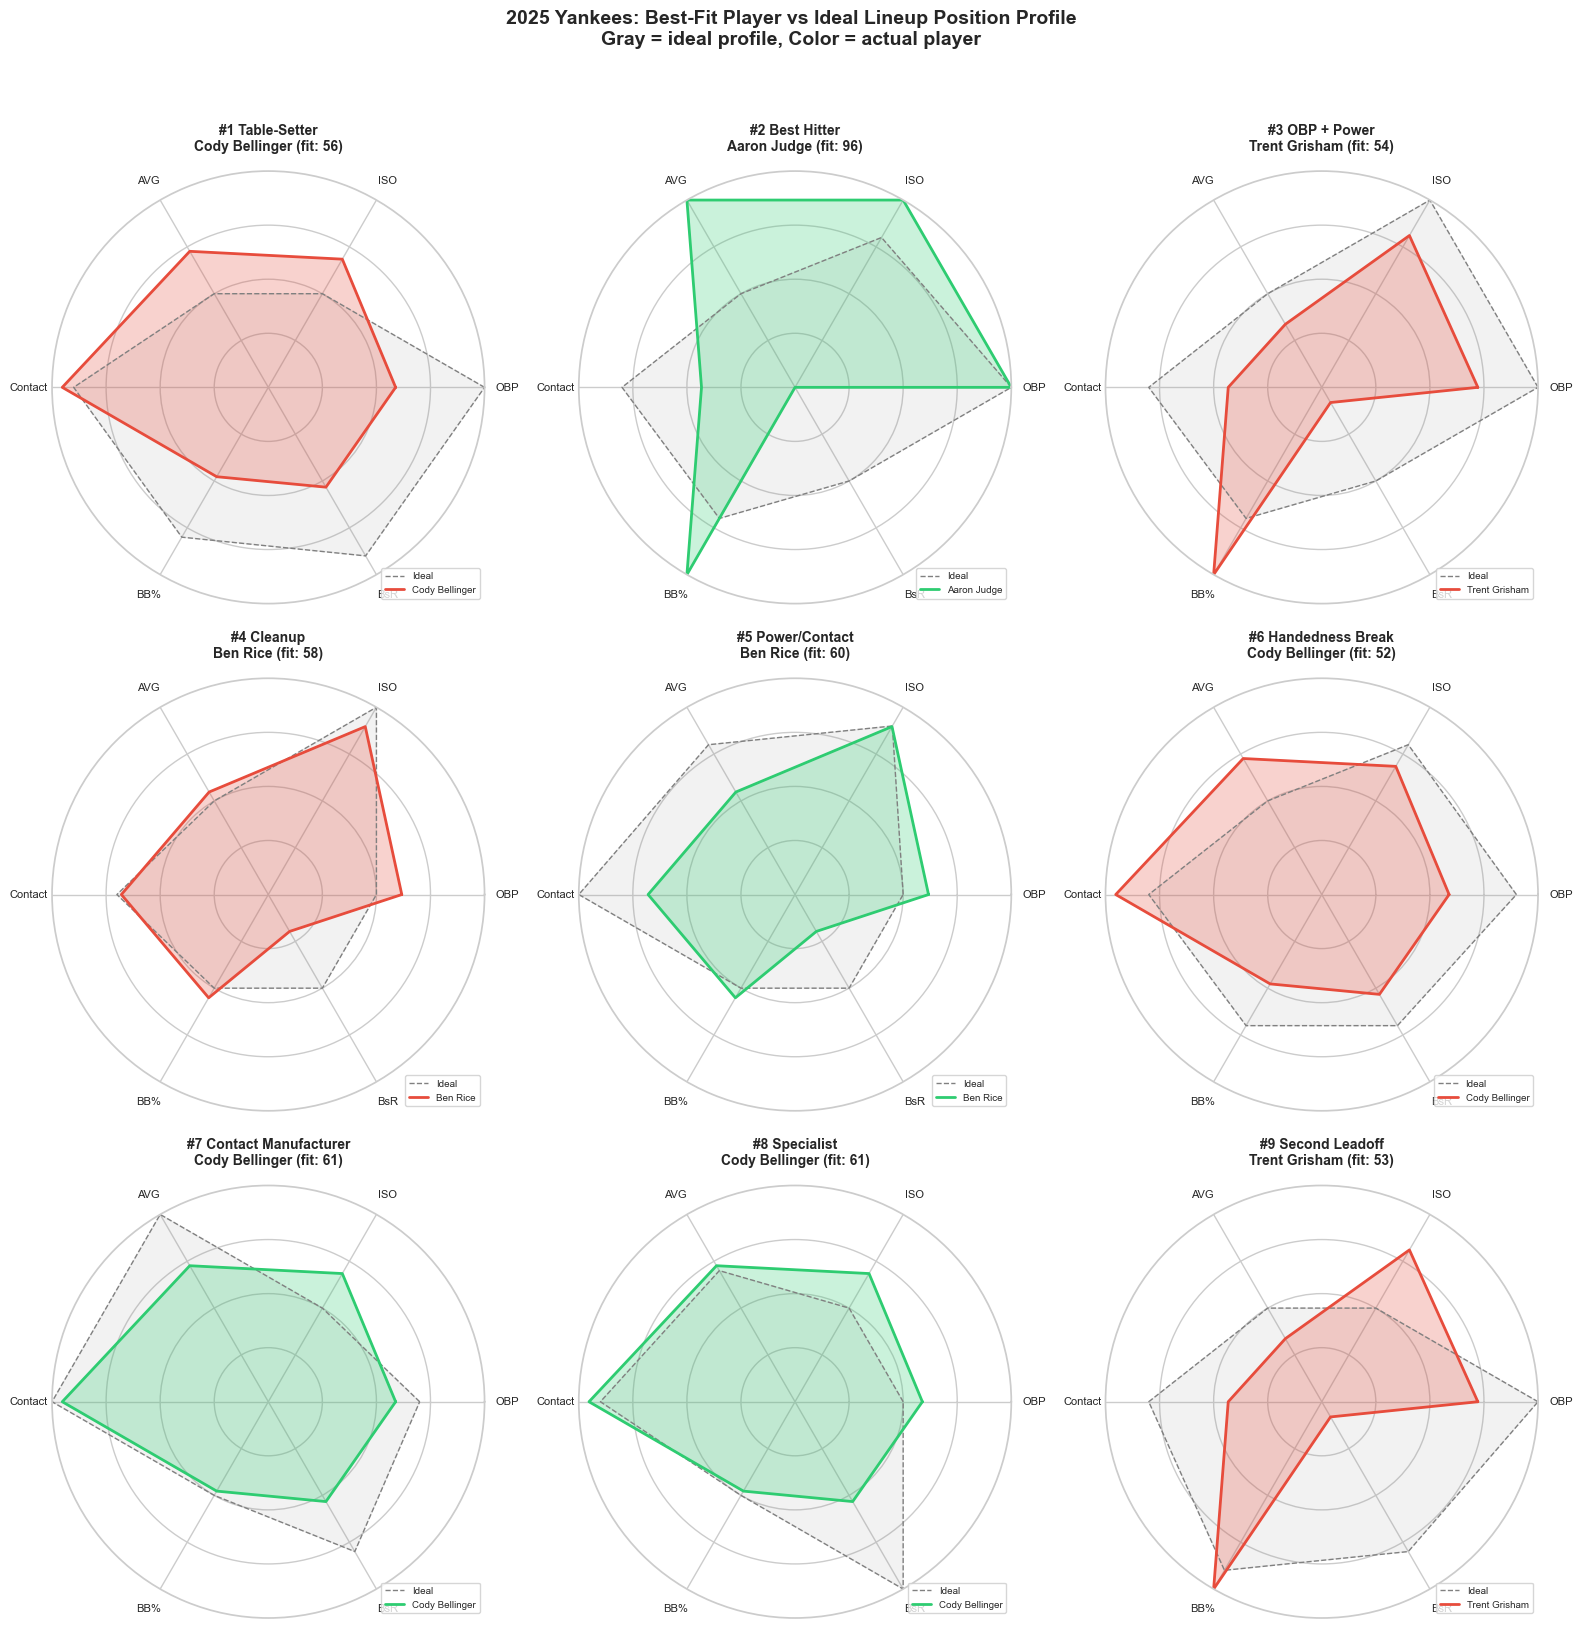

In [11]:
# Figure 3: Radar comparison — ideal profile vs actual best-fit Yankee
radar_stats = ["OBP", "ISO", "AVG"]
if k_col: radar_stats.append(k_col)
if bb_col: radar_stats.append(bb_col)
if bsr_col and bsr_col in qualified.columns: radar_stats.append(bsr_col)
radar_stats = radar_stats[:6]

stat_ranges = {}
for stat in radar_stats:
    if stat in qualified.columns:
        vals = pd.to_numeric(qualified[stat], errors="coerce").dropna()
        stat_ranges[stat] = (vals.quantile(0.05), vals.quantile(0.95))

def normalize_stat(value, stat):
    if stat not in stat_ranges or pd.isna(value):
        return 0.5
    lo, hi = stat_ranges[stat]
    if stat == k_col:
        return 1 - np.clip((value - lo) / (hi - lo), 0, 1)
    return np.clip((value - lo) / (hi - lo), 0, 1)


fig, axes = plt.subplots(3, 3, figsize=(16, 16), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(radar_stats), endpoint=False).tolist()
angles += angles[:1]

stat_labels = ["Contact" if s == k_col else s for s in radar_stats]

for idx, (_, row) in enumerate(gap_df.iterrows()):
    ax = axes[idx // 3][idx % 3]
    spot = int(row["spot"])
    name = row["best_fit"]
    
    player = nyy_25_teams[nyy_25_teams["Name"] == name]
    if len(player) == 0:
        continue
    player = player.iloc[0]
    
    player_vals = [normalize_stat(player.get(s, np.nan), s) for s in radar_stats]
    player_vals += player_vals[:1]
    
    profile = LINEUP_PROFILES[spot]
    ideal_vals = []
    for stat in radar_stats:
        w = profile["weights"].get(stat, 0)
        if stat == k_col:
            ideal_vals.append(0.5 + abs(w) * 2)
        else:
            ideal_vals.append(0.5 + w * 2)
    ideal_vals = [np.clip(v, 0, 1) for v in ideal_vals]
    ideal_vals += ideal_vals[:1]
    
    ax.fill(angles, ideal_vals, alpha=0.1, color="gray")
    ax.plot(angles, ideal_vals, "--", color="gray", linewidth=1, label="Ideal")
    color = "#2ecc71" if row["best_score"] >= 60 else "#e74c3c"
    ax.fill(angles, player_vals, alpha=0.25, color=color)
    ax.plot(angles, player_vals, "-", color=color, linewidth=2, label=name)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(stat_labels, fontsize=8)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels([])
    ax.set_title(f"#{spot} {profile['name']}\n{name} (fit: {row['best_score']:.0f})",
                fontsize=10, fontweight="bold", pad=15)
    ax.legend(loc="lower right", fontsize=7)

plt.suptitle("2025 Yankees: Best-Fit Player vs Ideal Lineup Position Profile\n"
             "Gray = ideal profile, Color = actual player",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../outputs/figures/yankees_lineup_radars.png", dpi=150, bbox_inches="tight")
plt.show()

## Takeaway

Judge is generational — he'd score highest everywhere on any roster. The diagnostic question is: **after you anchor him at #2, what does the rest of the lineup look like?**

- **Where the gaps show up**: Spots requiring a true table-setter (high OBP, low K%, speed) or a contact manufacturer (sub-20% K, puts ball in play) may lack a clean fit from the remaining roster.
- **Overloaded players**: When one non-star player is the best fit for 3+ spots, that means the roster doesn't have enough distinct archetypes.
- **The real finding**: This is a roster construction problem, not a lineup ordering problem. The order of the lineup matters much less than whether the right archetypes are on the roster in the first place.